<a href="https://colab.research.google.com/github/sparkyyyhd-bu/bu-rise-music/blob/social-media/explore_raw_wikipedia_reddit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reading the raw collected data: Wikipedia pageviews & Reddit r/all

The previous notebook (`explore_social_features.ipynb`) worked with the *processed* tables. This one opens the **raw collected data** underneath:

- **Wikipedia** — `data/raw/social/wikipedia/*.jsonl`: for each collected song, either a daily pageview time series for its verified article, or an explicit `no_article_found` marker.
- **Reddit r/all (official API)** — `data/raw/social/reddit/*.jsonl`: posts returned by per-song searches of all of Reddit. These are **search candidates, not yet verified matches** — verification happens in `04_match.py`.

Both use the same append-only *envelope* format, one JSON per line:
```json
{"platform": ..., "track_id_hint": "<spotify track id>", "query": "<what was searched>",
 "collected_at": "<utc timestamp>", "simulated": false, "payload": { ...platform-specific... }}
```

**Both collections are still in progress** (songs are processed in descending-popularity order, so the most popular songs are collected first). Re-running this notebook later will simply show more songs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "/content/drive/MyDrive/music/data/raw/social"

# song names for joining (raw envelopes only carry the track_id)
songs = pd.read_parquet(ROOT / "/content/drive/MyDrive/music/data/interim/canonical_songs.parquet")[
    ["track_id", "base_title", "primary_artist", "release_date", "popularity"]]
name_of = songs.set_index("track_id")


def read_envelopes(platform):
    """Yield every raw envelope for a platform, across all daily files."""
    for path in sorted((RAW / platform).glob("*.jsonl")):
        with open(path, encoding="utf-8") as fh:
            for line in fh:
                yield json.loads(line)

## 1. Wikipedia: daily pageview series per song

Payload kinds:
- `"pageviews"` — the verified article title plus `daily`: a list of `{date, views}` from 2015-07-01 (the API's earliest date) to collection time.
- `"no_article_found"` — the song was processed but no article passed the verification gate (title equality + artist named in the article + not a disambiguation/album page). Kept so coverage is measurable.

We load everything into two structures: a coverage table and a `track_id -> daily series` dict.

In [ ]:
wiki_rows, wiki_series = [], {}
for env in read_envelopes("wikipedia"):
    assert not env["simulated"]
    kind = env["payload"].get("kind")
    tid = env["track_id_hint"]
    wiki_rows.append({"track_id": tid, "kind": kind,
                      "article": env["payload"].get("article")})
    if kind == "pageviews" and env["payload"]["daily"]:
        s = pd.DataFrame(env["payload"]["daily"])
        s["date"] = pd.to_datetime(s["date"], format="%Y%m%d")
        wiki_series[tid] = s.set_index("date")["views"]

wiki = pd.DataFrame(wiki_rows).drop_duplicates("track_id", keep="last")
wiki = wiki.merge(songs, on="track_id", how="left")

print(f"songs processed so far: {len(wiki):,}")
print(wiki["kind"].value_counts().to_string())
print(f"-> article hit rate: {(wiki['kind'] == 'pageviews').mean():.1%} "
      "(popular songs first — this rate will fall as collection reaches obscure songs)")
wiki[wiki["kind"] == "pageviews"].head(5)[["base_title", "primary_artist", "article", "popularity"]]

songs processed so far: 7,963
kind
no_article_found    4523
pageviews           3440
-> article hit rate: 43.2% (popular songs first — this rate will fall as collection reaches obscure songs)


,base_title,primary_artist,article,popularity
0,Calma,Pedro Capó,Calma (song),97.0
1,Sweet but Psycho,Ava Max,Sweet but Psycho,97.0
2,Giant,Calvin Harris,Giant (Calvin Harris and Rag'n'Bone Man song),95.0
3,Baila Baila Baila,Ozuna,"Baila, Baila, Baila",95.0
4,Girls Just Want to Have Fun,Cyndi Lauper,Girls Just Want to Have Fun,76.0


### Pull the series for one song by name and plot it

'Girls Just Want to Have Fun' by Cyndi Lauper -> article 'Girls Just Want to Have Fun'
4,037 days | total 3,042,723 views | peak 4,735 on 2024-06-29


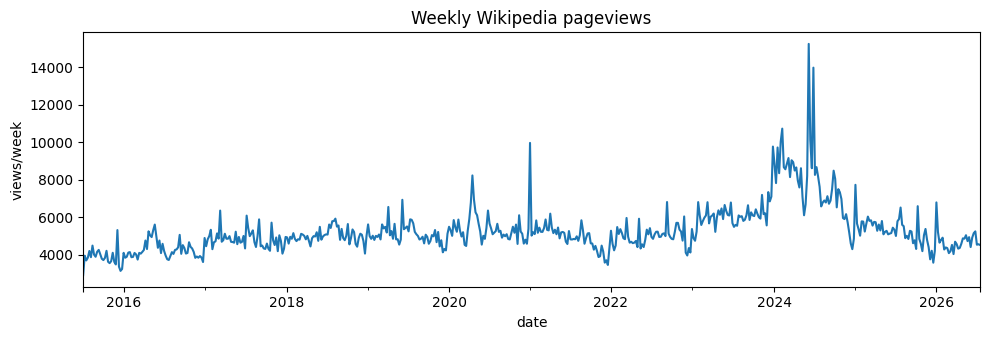

In [ ]:
def wiki_views(title, artist=None):
    """Daily pageview Series for a song, found by (title, artist) name."""
    hits = wiki[(wiki["kind"] == "pageviews")
                & (wiki["base_title"].str.lower() == title.lower())]
    if artist:
        hits = hits[hits["primary_artist"].str.contains(artist, case=False, na=False)]
    if hits.empty:
        raise KeyError(f"{title!r} not in the collected-with-article set (yet)")
    row = hits.iloc[0]
    print(f"{row.base_title!r} by {row.primary_artist} -> article {row.article!r}")
    return wiki_series[row.track_id]


views = wiki_views("Girls Just Want to Have Fun")
ax = views.resample("W").sum().plot(figsize=(10, 3.5))
ax.set(title="Weekly Wikipedia pageviews", ylabel="views/week")
print(f"{len(views):,} days | total {views.sum():,} views | "
      f"peak {views.max():,} on {views.idxmax():%Y-%m-%d}")
plt.tight_layout()

The pageview API only reaches back to **2015-07-01**, so for older songs this measures *sustained/evergreen attention*, not release buzz. For songs released after mid-2015 you can slice the release window directly — that's exactly what the leakage-safe `*_7d/30d/...` features do:

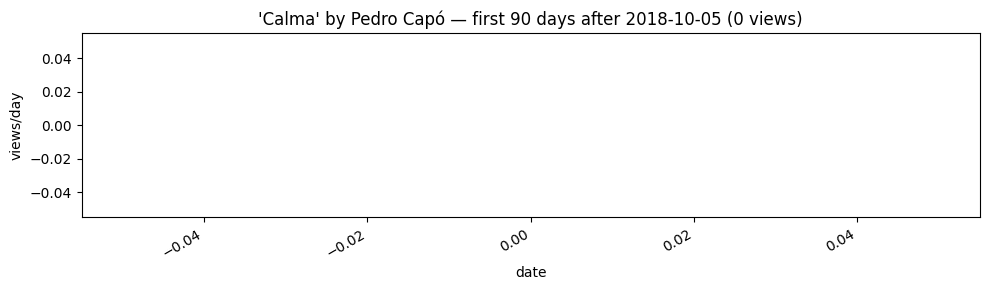

In [ ]:
# a post-2015 release: slice its first 90 days of attention
recent = wiki[(wiki["kind"] == "pageviews")
              & (pd.to_datetime(wiki["release_date"], errors="coerce") > "2016-01-01")]
row = recent.sort_values("popularity", ascending=False).iloc[0]
series = wiki_series[row.track_id]
release = pd.to_datetime(row.release_date)
window = series[release: release + pd.Timedelta(days=90)]

ax = window.plot(figsize=(10, 3), title=(
    f"{row.base_title!r} by {row.primary_artist} — first 90 days after "
    f"{release:%Y-%m-%d} ({int(window.sum()):,} views)"))
ax.set(ylabel="views/day")
plt.tight_layout()

## 2. Reddit r/all (official API)

Each envelope's payload is one Reddit post returned by a quoted `"Title" "Artist"` search over all of Reddit. Two crucial differences from the archive data:

1. **Breadth**: results can come from *any* subreddit, not just the 15 archived music communities.
2. **Recency bias**: Reddit's search heavily favors recent posts — quantified below.

These are raw *candidates*. To use them in features, verify them with the same scorer as everything else: `python3 scripts/04_match.py --platforms reddit reddit_archive` (list both platforms — the match table is rebuilt whole).

In [ ]:
reddit_rows = []
for env in read_envelopes("reddit"):
    assert not env["simulated"]
    p = env["payload"]
    reddit_rows.append({
        "track_id": env["track_id_hint"], "query": env["query"],
        "post_id": p.get("id"), "created_utc": p.get("created_utc"),
        "subreddit": p.get("subreddit"), "title": (p.get("title") or "")[:200],
        "score": p.get("score"), "num_comments": p.get("num_comments")})

rall = pd.DataFrame(reddit_rows)
rall["created"] = pd.to_datetime(rall["created_utc"], unit="s", errors="coerce")

print(f"raw candidate posts: {len(rall):,} for {rall['track_id'].nunique():,} songs")
print(f"distinct subreddits: {rall['subreddit'].nunique():,}  "
      "(vs 15 in the archive — this is the breadth the r/all sample adds)")
rall["subreddit"].value_counts().head(10)

raw candidate posts: 267,589 for 2,805 songs
distinct subreddits: 20,115  (vs 15 in the archive — this is the breadth the r/all sample adds)


,count
subreddit,
hiphopheads,9577
Music,9552
popheads,7778
kpop,3824
coversongs,3313
mashups,2965
EDM,2623
BestofRedditorUpdates,2548
TheTikiHut,2447


### Candidates for one song by name

In [ ]:
def rall_posts(title, artist=None):
    """Raw r/all search candidates for a song (unverified!)."""
    s = songs[songs["base_title"].str.lower() == title.lower()]
    if artist:
        s = s[s["primary_artist"].str.contains(artist, case=False, na=False)]
    out = rall[rall["track_id"].isin(s["track_id"])]
    return out.sort_values("created")[
        ["created", "subreddit", "title", "score", "num_comments"]]


# collection is popularity-ordered and still partial, so pick a song that is
# definitely in the collected set: the one with the most candidates so far
top_tid = rall["track_id"].value_counts().idxmax()
example = name_of.loc[top_tid]
print(f"most-searched-hit song so far: {example.base_title!r} by {example.primary_artist}")

posts_one = rall_posts(example.base_title, artist=example.primary_artist)
print(f"{len(posts_one)} candidate posts")
posts_one.tail(8)

most-searched-hit song so far: 'Shotgun' by George Ezra
369 candidate posts


,created,subreddit,title,score,num_comments
10165,2026-06-27 16:24:49,EclipseMusicApp,Can only download songs from a few sections,2,2
10574,2026-06-27 16:24:49,EclipseMusicApp,Can only download songs from a few sections,2,2
10287,2026-07-12 17:49:43,PUBGMobile,GOODBYE; It was a good run. 2018-2026.,439,145
10265,2026-07-13 23:10:03,SVUncensored,Scott Bryce dead at 68 from cancer. Appeared i...,4,1
10461,2026-07-18 17:43:58,rickastley,Shotgun (George Ezra cover),10,0
10052,2026-07-18 17:43:58,rickastley,Shotgun (George Ezra cover),9,0
10460,2026-07-18 19:04:17,ukpopculture,Rick Astley - Shotgun (George Ezra cover),25,5
10051,2026-07-18 19:04:17,ukpopculture,Rick Astley - Shotgun (George Ezra cover),23,5


### The recency bias, measured

Same plot for both Reddit sources: share of posts per year. The archive has a healthy historical shape; the official API's search results pile up in the last few years — this is why the archive route exists, and why r/all is used only as a complementary breadth sample.

,archive (accepted),r/all API (raw)
2008,0.001,0.000
2009,0.004,0.000
2010,0.011,0.000
2011,0.024,0.001
2012,0.063,0.003
2013,0.076,0.006
2014,0.065,0.009
2015,0.072,0.013
2016,0.083,0.019
2017,0.112,0.043


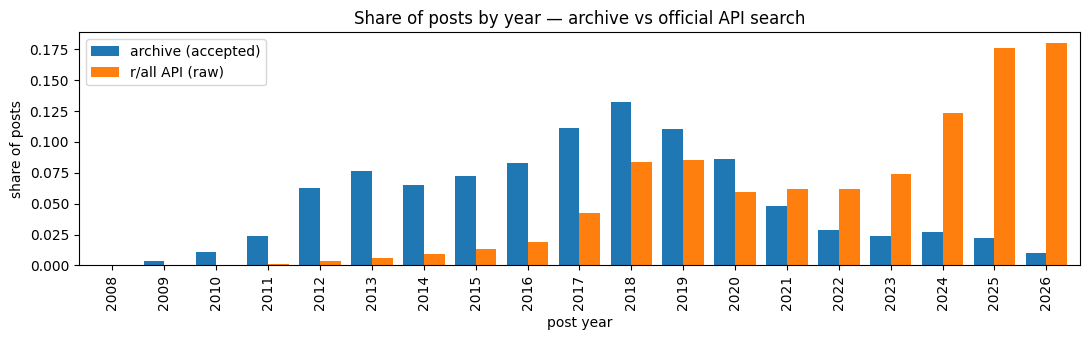

In [ ]:
matches = pd.read_parquet(ROOT / "/content/drive/MyDrive/music/data/interim/song_post_matches.parquet")
archive_years = pd.to_datetime(
    matches.loc[matches["decision"] == "accept", "created_utc"],
    unit="s", errors="coerce").dt.year
rall_years = rall["created"].dt.year

cmp = pd.DataFrame({
    "archive (accepted)": archive_years.value_counts(normalize=True),
    "r/all API (raw)": rall_years.value_counts(normalize=True),
}).sort_index().loc[2008:]

ax = cmp.plot.bar(figsize=(11, 3.5), width=0.8)
ax.set(title="Share of posts by year — archive vs official API search",
       ylabel="share of posts", xlabel="post year")
plt.tight_layout()
cmp.round(3)

## Caveats

- **Wikipedia**: series start 2015-07-01; articles exist mainly for notable songs (the hit rate above is inflated by popularity-first collection order). Verified at 100% precision on the pilot after three matcher fixes.
- **r/all**: *unverified candidates* — run them through `04_match.py` before using in features. Search returns at most ~100 posts per query (truncation correlates with popularity) and cannot reach most pre-2020 posts.
- Both collections are partial and growing; the checkpoint files in `data/checkpoints/` are the source of truth for how far each has gotten.
- Raw files are append-only — never edit them; derived tables belong in `data/interim/` or `data/processed/`.